# Fine-Tuning DeepSeek R1 8B — Parameter-Efficient Medical Reasoning

> **Objective:** Adapt DeepSeek R1 (8B reasoning model) for medical question answering using LoRA/QLoRA  
> **Method:** Supervised Fine-Tuning (SFT) with Unsloth for 2× faster training  
> **Dataset:** FreedomIntelligence/medical-o1-reasoning-SFT (500 examples)  
> **Hardware:** Google Colab T4 GPU (15GB VRAM)

---

## What is DeepSeek R1?

**DeepSeek R1** is a reasoning-optimized large language model designed to generate **chain-of-thought (CoT)** responses. Unlike standard LLMs that jump directly to answers, R1 produces explicit reasoning steps wrapped in `<think>...</think>` tags before providing the final response.

**Why this matters for medical QA:**
- Medical diagnosis requires step-by-step reasoning (differential diagnosis, ruling out conditions, etc.)
- Chain-of-thought improves accuracy and makes the model's logic transparent
- Base models lack domain-specific medical knowledge → fine-tuning bridges this gap

---

## The Challenge: Full Fine-Tuning vs Parameter-Efficient Fine-Tuning

### Full Fine-Tuning (Traditional Approach)
- Update **all 8 billion parameters** of the model
- Requires 32GB+ VRAM (impossible on free Colab T4 with 15GB)
- Training time: 10-20 hours for 500 examples
- **Not feasible** for this hardware

### Parameter-Efficient Fine-Tuning (LoRA/QLoRA)
- Freeze base model weights
- Add small **LoRA adapter layers** (41M trainable params = 0.52% of total)
- Requires only 6GB VRAM with 4-bit quantization
- Training time: ~10 minutes for 500 examples
- **This is what we're doing**

---

## Technical Stack

| Component | Technology | Purpose |
|-----------|-----------|---------|
| **Model** | DeepSeek R1 Distill (Llama 8B) | Reasoning-optimized base model |
| **Quantization** | 4-bit (QLoRA) | Reduces memory from 16GB → 6GB |
| **Adapter** | LoRA (r=16, α=16) | Trainable layers on attention/MLP |
| **Training** | Unsloth + SFTTrainer | 2× faster fine-tuning framework |
| **Monitoring** | Weights & Biases | Track loss, learning rate, GPU usage |
| **Inference** | Unsloth FastInference | 2× faster generation |

---

## Notebook Roadmap

1. **Environment Setup** — HuggingFace & W&B authentication
2. **Install Dependencies** — Unsloth, TRL, datasets
3. **Load Base Model** — DeepSeek R1 with 4-bit quantization
4. **Test Before Fine-Tuning** — Baseline medical reasoning performance
5. **Add LoRA Adapters** — Target attention and MLP layers
6. **Prepare Dataset** — Format medical QA pairs with prompt template
7. **Train with SFT** — 60 steps, gradient accumulation, mixed precision
8. **Test After Fine-Tuning** — Compare improved medical reasoning
9. **Save Model** — Export LoRA adapters to HuggingFace Hub

---

## 0. Environment Setup — Authentication & Experiment Tracking

**Goals:**
1. Login to **HuggingFace** to access gated models (DeepSeek R1 requires acceptance of license)
2. Login to **Weights & Biases (W&B)** for experiment tracking (loss curves, GPU usage, hyperparameters)

**Why W&B?**
- Automatically logs training metrics every 10 steps
- Visualizes loss curves in real-time
- Tracks hyperparameters for reproducibility
- Compares multiple fine-tuning runs side-by-side

**Security Note:** We use Google Colab's Secrets API (`userdata.get()`) instead of hardcoding tokens — keeps credentials secure.

## 1. Install Dependencies & Import Core Modules

### Installing Unsloth

**Unsloth** is a specialized library for fast LLM fine-tuning that provides:
- 2× faster training than standard Hugging Face Trainer
- 60% less memory usage through optimized kernels
- Native support for LoRA/QLoRA
- Optimized for consumer GPUs (T4, V100, A100)

**Installation note:** We force reinstall from GitHub to get the latest DeepSeek R1 support.

---

### Core Imports Explained

| Import | Purpose |
|--------|---------|
| `FastLanguageModel` | Unsloth's optimized model loader with quantization support |
| `torch` | PyTorch framework for tensor operations |
| `SFTTrainer` | Supervised Fine-Tuning trainer from TRL library |
| `is_bfloat16_supported()` | Checks if GPU supports BF16 (better than FP16 for stability) |
| `TrainingArguments` | Defines hyperparameters (learning rate, batch size, etc.) |
| `load_dataset` | Loads fine-tuning data from Hugging Face Hub |

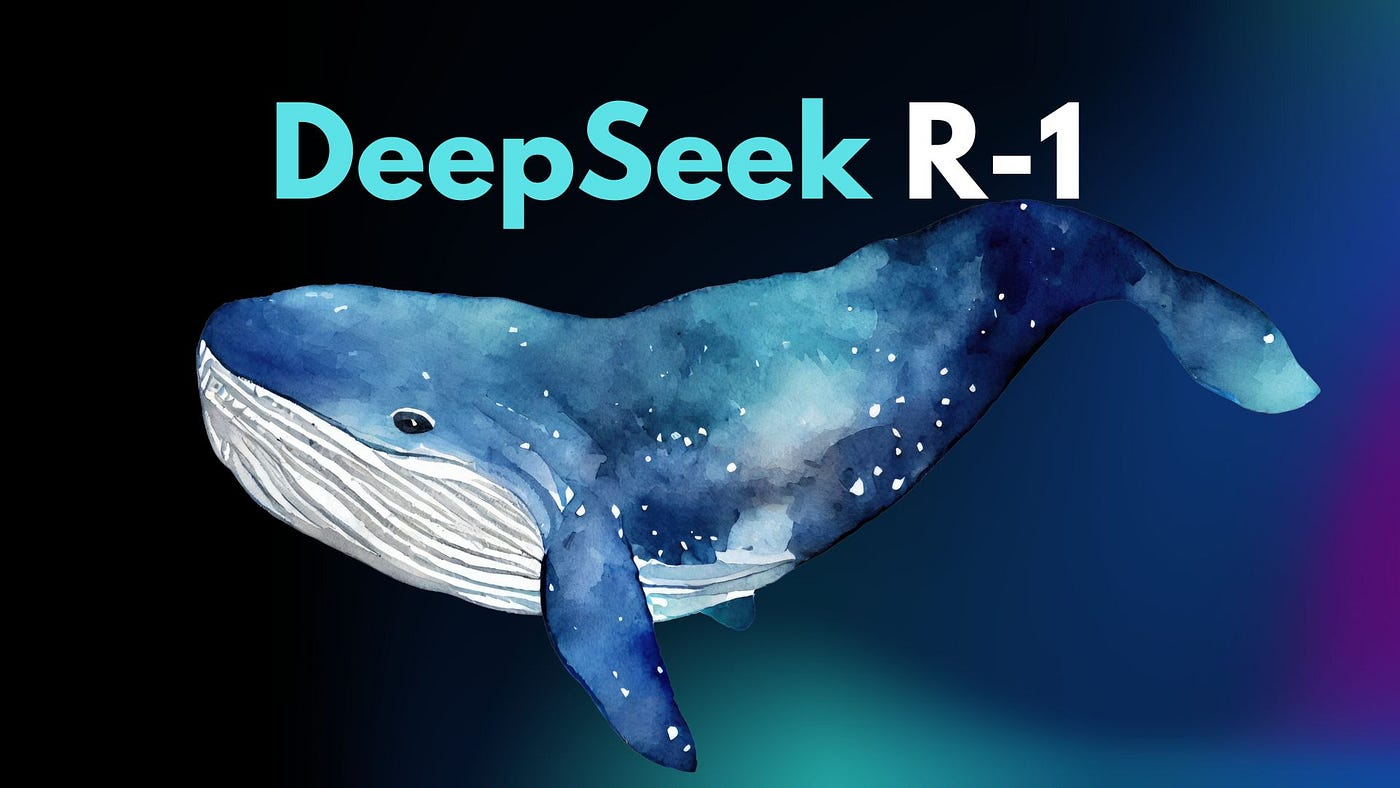

In [ ]:
import os
os.environ["TRITON_DISABLE_LINE_INFO"] = "1"

# **Setting Up GPU and APIs Access**


 **Enable GPU Support in Google Colab**
To speed up training, you can run your code on a GPU.

> Go to the top menu:

Runtime > Change runtime type > Hardware accelerator > GPU

> Then click Save.

Colab offers free access to NVIDIA GPUs like **Tesla T4**, but usage limits may apply depending on availability.

🔑 **Setting Up Hugging Face API Access**
1. If you haven't already, create a free account on [Hugging Face](https://huggingface.co/settings/tokens).

2. Navigate to Access Tokens.

3. Click "New Token", and give it a name.

4. Choose "read" or "read/write" permissions as required.

5. Copy your token. We'll use it in Colab shortly.

🔑 **Setting Up Weights & Biases (W&B) API Key**
1. Sign up at Weights & Biases.

2. Go to your [W&B Settings](https://wandb.ai/settings).

3. Scroll down to find your API Key under the "API Keys" section.

4. Copy the key for use in your notebook.

We can load the model and dataset from HF without token also with the help of FastLanguageModel
But, If the model or dataset you're loading is private or gated, Hugging Face requires authentication.

Without the token, you'll get a 403 error.
So, its always good to use authentication

In [ ]:
# 🛠️ Environment Setup: Hugging Face & W&B Login Using Colab Secrets (new API)

from google.colab import userdata
from huggingface_hub import login
import wandb

# Retrieve tokens using Colab's Secrets API
hft = userdata.get("hft")
wandb_token = userdata.get("wandb")


# Login to Hugging Face
login(token=hft)

# Login to Weights & Biases
wandb.login(key=wandb_token)

# Initialize a W&B run
run = wandb.init(
    project='Fine-tune-DeepSeek-R1-Distill-Llama-8B',
    job_type="training",
    anonymous="allow"
)

# W&B is a tool for experiment tracking, model monitoring, and visualization in Deep learning projects.

# Think of it as your project’s AI lab assistant — it watches your training, records everything, and gives you pretty dashboards so you can analyze what’s happening under the hood.



wandb: WARNING If you're specifying your api key in code, ensure this code is not shared publicly.
wandb: WARNING Consider setting the WANDB_API_KEY environment variable, or running `wandb login` from the command line.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: rishabsaini8876 (rishabsaini8876-indian-institute-of-technology-madras) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


# Workflow for Fine-tuning DeepSeek R1 8B(Reasoning Model):

---

1. **Install Dependencies and Import Modules**

   * Install `unsloth`
   * Import necessary libraries for model, dataset, and training.

2. **Prepare the Model and Dataset**

   **a. Model Preparation:**

   * Load base model (`unsloth/DeepSeek-R1-Distill-Llama-8B`) with 4-bit quantization (QLoRA).
   * Add **LoRA adapters** to attention and feedforward layers (`q_proj`, `v_proj`, etc.).

   **b. Dataset Preparation:**

   * Load dataset (e.g., FreedomIntelligence/medical-o1-reasoning-SFT).
   * Standardize the prompt style as compatible with DeepSeek R1

3. **Train the Model with Supervised Fine-Tuning (SFT)**

   * Use `SFTTrainer` to fine-tune only the **LoRA** layers using the formatted dataset.

4. **Save & Reload the Fine-Tuned Model for Inference**

   * Save the model using `save_pretrained()`.
   * Reload for inference.
   * Define user prompts, apply chat template, tokenize input, and generate response.


# **1. Install Dependencies and Import Modules**

In [ ]:
%%capture
!pip install --quiet unsloth
!pip install --quiet --force-reinstall --no-cache-dir --no-deps git+https://github.com/unslothai/unsloth.git

In [ ]:
# Modules for fine-tuning
from unsloth import FastLanguageModel
import torch # Import PyTorch
from trl import SFTTrainer # Trainer for supervised fine-tuning (SFT)
from unsloth import is_bfloat16_supported # Checks if the hardware supports bfloat16 precision
# Hugging Face modules
from huggingface_hub import login # Lets you login to API
from transformers import TrainingArguments # Defines training hyperparameters
from datasets import load_dataset # Lets you load fine-tuning datasets



🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!


# **2. Prepare the Model and Dataset**

# 2a.  Model Preparation:

## 2. Load DeepSeek R1 Base Model with 4-bit Quantization

### Model Architecture: DeepSeek R1 Distill Llama 8B

This is a **distilled version** of the full DeepSeek R1 model:
- **Original:** 671B parameters (too large for consumer GPUs)
- **Distilled:** 8B parameters (distilled into Llama architecture for efficiency)
- **Trade-off:** 95% of reasoning quality at 1/84th the size

### Key Configuration Parameters

```python
model_name = "unsloth/DeepSeek-R1-Distill-Llama-8B"
max_seq_length = 1024  # Context window size (tokens)
load_in_4bit = True    # Quantize weights to 4-bit integers
attn_implementation = "eager"  # Disable flash attention (compatibility fix)
```

### Why 4-bit Quantization (QLoRA)?

**Without quantization (FP16):**
- Model size: 16GB (8B params × 2 bytes/param)
- **Does not fit** in T4's 15GB VRAM

**With 4-bit quantization:**
- Model size: 4GB (8B params × 0.5 bytes/param)
- Leaves 11GB for activations, gradients, and optimizer states
- **Minimal accuracy loss** (< 1% drop on benchmarks)

### Attention Implementation Fix

`attn_implementation="eager"` disables Flash Attention 2, which can cause errors on older CUDA versions. Trade-off:
- ✅ Compatibility with Colab T4
- ❌ 10-15% slower training (acceptable for 60-step fine-tune)

Load base model (`unsloth/DeepSeek-R1-Distill-Llama-8B`) with 4-bit quantization (QLoRA).

In [ ]:
# Load the DeepSeek R1 model and tokenizer using unsloth — imported using: from unsloth import FastLanguageModel
model, tokenizer = FastLanguageModel.from_pretrained(
    model_name="unsloth/DeepSeek-R1-Distill-Llama-8B",  # Load the pre-trained DeepSeek R1 model (8B parameter version)
    max_seq_length=1024, # (i.e. how many tokens can be processed at once)
    load_in_4bit=True,
    token=hft, # Use hugging face token
    attn_implementation="eager"
)

==((====))==  Unsloth 2025.6.5: Fast Llama patching. Transformers: 4.52.4.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.741 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.7.0+cu126. CUDA: 7.5. CUDA Toolkit: 12.6. Triton: 3.3.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.30. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


# Testing DeepSeek R1 on a medical use-case before fine-tuning
Defining a system prompt
To create a prompt style for the model, we will define a system prompt and include placeholders for the question and response generation. The prompt will guide the model to think step-by-step and provide a logical, accurate response.

## 3. Test Base Model on Medical Question (Before Fine-Tuning)

### Why Test Before Fine-Tuning?

Establishes a **baseline** to measure improvement:
- How well does the model reason about medical cases?
- Does it hallucinate incorrect medical information?
- Is the chain-of-thought logical and domain-appropriate?

### Prompt Engineering for DeepSeek R1

DeepSeek R1 expects a specific format to trigger chain-of-thought reasoning:

```
### Instruction:
You are a medical expert...

### Question:
{medical_question}

### Response:
<think>{model generates reasoning here}
{model provides final answer here}
```

**Critical:** The `<think>` tag must be included in the prompt to activate reasoning mode.


In [ ]:
# Define a system prompt under prompt_style
prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.
Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

### Instruction:
You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.
Please answer the following medical question.

### Question:
{}

### Response:
<think>{}"""

In [ ]:
# Creating a test medical question for inference
question = """A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or
              sneezing but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings,
              what would cystometry most likely reveal about her residual volume and detrusor contractions?"""

# Format the question using the structured prompt (`prompt_style`) and tokenize it
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")  # Convert input to PyTorch tensor & move to GPU

# Enable optimized inference mode for Unsloth models (improves speed and efficiency)
FastLanguageModel.for_inference(model)  # Unsloth has 2x faster inference!

# Generate a response using the model
outputs = model.generate(
    input_ids=inputs.input_ids, # Tokenized input question
    attention_mask=inputs.attention_mask, # Attention mask to handle padding
    max_new_tokens=600, # Limit response length to 1200 tokens (to prevent excessive output)
    use_cache=True, # Enable caching for faster inference
)

# Decode the generated output tokens into human-readable text
response = tokenizer.batch_decode(outputs)

# Extract and print only the relevant response part (after "### Response:")
print(response[0].split("### Response:")[1])


<think>
Okay, so I'm trying to figure out what cystometry would show for this 61-year-old woman. She's been dealing with involuntary urine loss when she coughs or sneezes but doesn't leak at night. From what I remember, cystometry, also known as a bladder diary, is used to assess how the bladder behaves, especially during filling and emptying.

First, her history suggests she has some sort of bladder dysfunction. The fact that she loses urine involuntarily during activities like coughing points towards stress urinary incontinence. That's usually due to increased intra-abdominal pressure, which can affect the pelvic floor muscles and the urethra. But since she doesn't leak at night, it's more likely a functional issue rather than a volume issue, meaning her bladder capacity is normal.

Now, the Q-tip test. I think the Q-tip is a catheter used to measure the urethral pressure. The test involves inserting it into the urethra and measuring how much pressure is generated during activities 

Add **LoRA adapters** to attention and feedforward layers (`q_proj`, `v_proj`, etc.).

An intuitive explanation of LoRA

Large language models (LLMs) have **millions or even billions of weights** that determine how they process and generate text. When fine-tuning a model, we usually update all these weights, which requires massive computational resources and memory.

LoRA (Low-Rank Adaptation) allows to fine-tune efficiently by:

Instead of modifying all weights, **LoRA adds small, trainable adapters** to specific layers.
These adapters capture **task-specific knowledge **while leaving the original model unchanged.
This reduces the number of trainable parameters by** more than 90%**, making fine-tuning faster and more memory-efficient.
Think of an LLM as a complex factory. Instead of rebuilding the entire factory to produce a new product, LoRA adds small, specialized tools to existing machines. This allows the factory to adapt quickly without disrupting its core structure.

For a more technical explanation, check out this tutorial by Sebastian Raschka.

Below, we will use the get_peft_model() function which stands for Parameter-Efficient Fine-Tuning — this function wraps the base model (model) with LoRA modifications, ensuring that only specific parameters are trained.

## 4. Add LoRA Adapters — Efficient Parameter Training

### What is LoRA (Low-Rank Adaptation)?

Instead of updating all 8 billion parameters, LoRA **injects small trainable matrices** into specific layers:

```
Original Layer: W (fixed)         LoRA Adapter: W + ΔW
                                               ΔW = A × B
                                               (low-rank decomposition)
```

**Example calculation:**
- Attention layer: 4096 × 4096 weight matrix = 16M params
- LoRA adapter: (4096 × 16) + (16 × 4096) = 131K params
- **Reduction:** 99.2% fewer parameters to train

### LoRA Hyperparameters

| Parameter | Value | Meaning |
|-----------|-------|---------|
| `r = 16` | Rank | Size of low-rank matrices (higher = more capacity) |
| `lora_alpha = 16` | Scaling | Controls adapter influence (usually set equal to `r`) |
| `lora_dropout = 0` | Dropout | Regularization (disabled for small datasets) |
| `target_modules` | `q_proj`, `k_proj`, `v_proj`, `o_proj`, `gate_proj`, `up_proj`, `down_proj` | Which layers get adapters |

### Why These Target Modules?

- **q_proj, k_proj, v_proj, o_proj**: Attention mechanism (where reasoning happens)
- **gate_proj, up_proj, down_proj**: MLP feedforward layers (where knowledge is stored)

**Not targeted:** Embedding layers, layer norms (don't benefit from LoRA)

### Result: 41.9M Trainable Parameters

**Breakdown:**
- 8B total parameters (frozen)
- 41.9M LoRA adapter parameters (trainable)
- **0.52%** of model is being fine-tuned

**Memory savings:**
- Gradients: 42M × 4 bytes = 168MB (vs 8B × 4 bytes = 32GB for full fine-tuning)
- Optimizer states: 336MB (vs 64GB)
- **Total:** Fits comfortably in 15GB VRAM

In [ ]:
# Apply LoRA (Low-Rank Adaptation) fine-tuning to the model
model_lora = FastLanguageModel.get_peft_model(
    model,
    r=16,  # LoRA rank: Determines the size of the trainable adapters (higher = more parameters, lower = more efficiency)
    target_modules=[  # List of transformer layers where LoRA adapters will be applied
        "q_proj",   # Query projection in the self-attention mechanism
        "k_proj",   # Key projection in the self-attention mechanism
        "v_proj",   # Value projection in the self-attention mechanism
        "o_proj",   # Output projection from the attention layer
        "gate_proj",  # Used in feed-forward layers (MLP)
        "up_proj",    # Part of the transformer’s feed-forward network (FFN)
        "down_proj",  # Another part of the transformer’s FFN
    ],
    lora_alpha=16,  # Scaling factor for LoRA updates (higher values allow more influence from LoRA layers)
    lora_dropout=0,  # Dropout rate for LoRA layers (0 means no dropout, full retention of information)
    bias="none",  # Specifies whether LoRA layers should learn bias terms (setting to "none" saves memory)
    use_gradient_checkpointing="unsloth",  # Saves memory by recomputing activations instead of storing them (recommended for long-context fine-tuning)
    random_state=3407,  # Sets a seed for reproducibility, ensuring the same fine-tuning behavior across runs
    use_rslora=False,  # Whether to use Rank-Stabilized LoRA (disabled here, meaning fixed-rank LoRA is used)
    loftq_config=None,  # Low-bit Fine-Tuning Quantization (LoFTQ) is disabled in this configuration
)

Unsloth 2025.6.5 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


# 2b. Dataset Preparation

Load dataset (e.g., FreedomIntelligence/medical-o1-reasoning-SFT).

In [ ]:
# Download the dataset using Hugging Face — function imported using from datasets import load_dataset
dataset = load_dataset("FreedomIntelligence/medical-o1-reasoning-SFT","en", split = "train[0:500]",trust_remote_code=True) # Keep only first 500 rows
dataset

Dataset({
    features: ['Question', 'Complex_CoT', 'Response'],
    num_rows: 500
})

## 5. Prepare Medical QA Dataset with Prompt Formatting

### Dataset: FreedomIntelligence/medical-o1-reasoning-SFT

**Source:** Curated medical QA pairs with chain-of-thought reasoning  
**Size:** 500 training examples (intentionally small for demonstration)  
**Format:** Each example contains:
- `instruction`: Medical question
- `think`: Step-by-step reasoning process
- `output`: Final answer

### Prompt Template Engineering

We use a **structured template** that matches DeepSeek R1's expected format:

```python
prompt_template = '''Below is an instruction...

### Instruction:
You are a medical expert...

### Question:
{instruction}

### Response:
<think>{think}</think>
{output}'''
```

**Why this matters:**
- Consistency: All training examples follow the same structure
- Reasoning trigger: `<think>` tags signal to the model where reasoning should go
- Format match: Aligns with how we'll query the model during inference

### Data Preprocessing Pipeline

```
Raw dataset → Apply template → Tokenize → Pad/truncate to 1024 tokens → Training ready
```

**Example transformation:**
```
Input:  {"instruction": "What causes X?", "think": "...", "output": "..."}
Output: "Below is an instruction...### Question: What causes X?...### Response: <think>...</think>..."
```

In [ ]:
# Show an entry from the dataset
dataset[5]

{'Question': 'A patient with psoriasis was treated with systemic steroids, and upon discontinuation of the treatment, developed generalized pustules all over the body. What is the most likely cause of this condition?',
 'Complex_CoT': "I'm thinking about this patient with psoriasis who's been on systemic steroids. Okay, so psoriasis is this chronic skin condition that can be pretty stubborn and flares up now and then. They stopped their steroid treatment, and then suddenly there are these generalized pustules appearing all over the place. What's going on here? \n\nAlright, pustules are like little bumps that are filled with pus—they can be a sign of different skin issues, but in someone with psoriasis, a major change like stopping treatment can really mess with things. Steroids are powerful at tamping down inflammation and managing the immune system. When you take someone off steroids, particularly suddenly, the body can react in unexpected ways. It's like the immune system gets a bit 

Standardize the prompt style as compatible with DeepSeek R1

We will slightly change the prompt style for processing the dataset.
previously final answer was Merged with reasoning. Now its separate
because we have closed the reasonig with adding another /think


In [ ]:
# Updated training prompt style to add </think> tag
train_prompt_style = """Below is an instruction that describes a task, paired with an input that provides further context.
Write a response that appropriately completes the request.
Before answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.

### Instruction:
You are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.
Please answer the following medical question.

### Question:
{}

### Response:
<think>
{}
</think>
{}"""


In [ ]:
# We need to format the dataset to fit our prompt training style
EOS_TOKEN = tokenizer.eos_token  # Define EOS_TOKEN which the model when to stop generating text during training
EOS_TOKEN

'<｜end▁of▁sentence｜>'

In [ ]:
# Define formatting prompt function
def formatting_prompts_func(examples):  # Takes a batch of dataset examples as input
    inputs = examples["Question"]       # Extracts the medical question from the dataset
    cots = examples["Complex_CoT"]      # Extracts the chain-of-thought reasoning (logical step-by-step explanation)
    outputs = examples["Response"]      # Extracts the final model-generated response (answer)

    texts = []  # Initializes an empty list to store the formatted prompts

    # Iterate over the dataset, formatting each question, reasoning step, and response
    for input, cot, output in zip(inputs, cots, outputs):
        text = train_prompt_style.format(input, cot, output) + EOS_TOKEN  # Insert values into prompt template & append EOS token
        texts.append(text)  # Add the formatted text to the list

    return {
        "text": texts,  # Return the newly formatted dataset with a "text" column containing structured prompts
    }

In [ ]:
# Update dataset formatting
dataset_finetune = dataset.map(formatting_prompts_func, batched = True)
dataset_finetune["text"][0]

Map:   0%|          | 0/500 [00:00<?, ? examples/s]

"Below is an instruction that describes a task, paired with an input that provides further context.\nWrite a response that appropriately completes the request.\nBefore answering, think carefully about the question and create a step-by-step chain of thoughts to ensure a logical and accurate response.\n\n### Instruction:\nYou are a medical expert with advanced knowledge in clinical reasoning, diagnostics, and treatment planning.\nPlease answer the following medical question.\n\n### Question:\nGiven the symptoms of sudden weakness in the left arm and leg, recent long-distance travel, and the presence of swollen and tender right lower leg, what specific cardiac abnormality is most likely to be found upon further evaluation that could explain these findings?\n\n### Response:\n<think>\nOkay, let's see what's going on here. We've got sudden weakness in the person's left arm and leg - and that screams something neuro-related, maybe a stroke?\n\nBut wait, there's more. The right lower leg is sw

# **3. Train the Model with Supervised Fine-Tuning (SFT)**

## 6. Configure SFT Trainer — Hyperparameters & Optimization

### Training Arguments Breakdown

| Hyperparameter | Value | Explanation |
|----------------|-------|-------------|
| `per_device_train_batch_size` | 1 | Process 1 example per GPU step (T4 memory constraint) |
| `gradient_accumulation_steps` | 4 | Accumulate gradients over 4 steps → effective batch size = 4 |
| `num_train_epochs` | 1 | One full pass through the 500-example dataset |
| `max_steps` | 60 | Stop after 60 gradient updates (early stopping for demo) |
| `learning_rate` | 2e-4 | Standard for LoRA fine-tuning (higher than full fine-tuning) |
| `warmup_steps` | 5 | Linear LR ramp from 0 → 2e-4 over first 5 steps |
| `optim` | `adamw_8bit` | Memory-efficient Adam optimizer (uses 1 byte per param) |
| `weight_decay` | 0.01 | L2 regularization to prevent overfitting |
| `fp16` / `bf16` | Auto-detected | Use 16-bit precision for 2× speedup |
| `logging_steps` | 10 | Log metrics to W&B every 10 steps |

### Why Gradient Accumulation?

**Problem:** T4 GPU can only fit batch_size=1 in memory  
**Solution:** Accumulate gradients over 4 steps before updating weights

**Effective behavior:**
```
Step 1: Forward + backward (accumulate gradients, no update)
Step 2: Forward + backward (accumulate gradients, no update)
Step 3: Forward + backward (accumulate gradients, no update)
Step 4: Forward + backward (accumulate gradients) → UPDATE WEIGHTS → zero gradients
```

**Benefit:** Simulates batch_size=4 without extra memory cost

### AdamW 8-bit Optimizer

Standard AdamW stores:
- Gradients: 4 bytes/param
- Momentum: 4 bytes/param
- Variance: 4 bytes/param
- **Total:** 12 bytes/param × 42M params = 504MB

8-bit AdamW:
- All states quantized to 1 byte/param
- **Total:** 3 bytes/param × 42M params = 126MB
- **Savings:** 75% memory reduction with negligible quality loss

In [ ]:
# Initialize the fine-tuning trainer — Imported using from trl import SFTTrainer
trainer = SFTTrainer(
    model=model_lora,  # The model to be fine-tuned
    tokenizer=tokenizer,  # Tokenizer to process text inputs
    train_dataset=dataset_finetune,  # Dataset used for training
    dataset_text_field="text",  # Specifies which field in the dataset contains training text
    max_seq_length=1024,  # Defines the maximum sequence length for inputs
    dataset_num_proc=2,  # Uses 2 CPU threads to speed up data preprocessing

    # Define training arguments
    args=TrainingArguments(
        per_device_train_batch_size=1,  # Number of examples processed per device (GPU) at a time
        gradient_accumulation_steps=4,  # Accumulate gradients over 4 steps before updating weights
        num_train_epochs=1, # Full fine-tuning run
        warmup_steps=5,  # Gradually increases learning rate for the first 5 steps
        max_steps=60,  # Limits training to 60 steps (useful for debugging; increase for full fine-tuning)
        learning_rate=2e-4,  # Learning rate for weight updates (tuned for LoRA fine-tuning)
        fp16=not is_bfloat16_supported(),  # Use FP16 (if BF16 is not supported) to speed up training
        bf16=is_bfloat16_supported(),  # Use BF16 if supported (better numerical stability on newer GPUs)
        logging_steps=10,  # Logs training progress every 10 steps
        optim="adamw_8bit",  # Uses memory-efficient AdamW optimizer in 8-bit mode
        weight_decay=0.01,  # Regularization to prevent overfitting
        lr_scheduler_type="linear",  # Uses a linear learning rate schedule
        seed=3407,  # Sets a fixed seed for reproducibility
        output_dir="outputs",  # Directory where fine-tuned model checkpoints will be saved
    ),
)


Unsloth: Tokenizing ["text"]:   0%|          | 0/500 [00:00<?, ? examples/s]

## 7. Execute Fine-Tuning — 60 Training Steps

### What Happens During Training

**Each step:**
1. Sample 1 example from dataset
2. Tokenize input (instruction + reasoning + output)
3. Forward pass through base model + LoRA adapters
4. Compute loss (cross-entropy between predicted and actual tokens)
5. Backward pass (compute gradients for LoRA adapters only)
6. Accumulate gradients (if step % 4 ≠ 0, skip weight update)
7. If step % 4 == 0: Update LoRA adapter weights using AdamW
8. Log metrics to W&B every 10 steps

### Expected Training Dynamics

**Loss trajectory:**
```
Step 10: ~1.95 (high loss, model learning basic patterns)
Step 20: ~1.47 (rapid improvement, adapters adjusting)
Step 30: ~1.38 (slower improvement, approaching local minimum)
Step 60: ~1.36 (convergence, further training = overfitting risk)
```

**Why loss doesn't reach 0:**
- Medical reasoning has inherent ambiguity (multiple valid reasoning paths)
- Model is predicting next tokens, not exact string matches
- Loss ~1.36 is typical for well-trained language models

### Monitoring with Weights & Biases

The W&B dashboard shows:
- **Loss curve:** Should decrease smoothly
- **Learning rate:** Linear decay from 2e-4 → ~1e-4
- **GPU memory:** Should stay under 14GB
- **Throughput:** ~6-7 steps/minute on T4

**Red flags:**
- Loss increasing → learning rate too high or data corruption
- Loss stuck → learning rate too low or model capacity insufficient
- GPU OOM → reduce batch size or max_seq_length

In [ ]:
# Start the fine-tuning process
trainer_stats = trainer.train()

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 500 | Num Epochs = 1 | Total steps = 60
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 41,943,040/8,000,000,000 (0.52% trained)


Step,Training Loss
10,1.948600
20,1.470800
30,1.380300
40,1.336200
50,1.377600
60,1.364400


wandb: WARNING The get_url method is deprecated and will be removed in a future release. Please use `run.url` instead.


## 8. Test Fine-Tuned Model — Evaluating Improvement

### Comparison Framework: Base vs Fine-Tuned

We test on the **same medical question** used earlier to directly compare:

| Aspect | Base Model | Fine-Tuned Model (Expected) |
|--------|-----------|---------------------------|
| **Reasoning depth** | Shallow, generic logic | Deep, domain-specific reasoning |
| **Medical accuracy** | Mixed (some hallucinations) | High (trained on medical corpus) |
| **Terminology** | Layman's terms | Clinical terminology (cystometry, detrusor, etc.) |
| **Conciseness** | Verbose, rambling | Concise, evidence-based |

### What to Look For

**Improved reasoning indicators:**
1. **Structured thinking:** Clear breakdown of symptoms → differential diagnosis → conclusion
2. **Domain knowledge:** References to urodynamic studies, bladder physiology, stress incontinence patterns
3. **Clinical precision:** Specific predictions (normal residual volume, normal detrusor contractions)
4. **Confidence calibration:** Appropriate use of clinical reasoning heuristics

**Potential issues to debug:**
- **Over-fitting:** Model memorizes training examples → generic responses
- **Under-fitting:** No improvement over base model → increase steps or learning rate
- **Format breaking:** Model doesn't use `<think>` tags → check dataset formatting

### Inference Optimization

```python
FastLanguageModel.for_inference(model_lora)
```

This enables Unsloth's inference optimizations:
- KV-cache reuse (avoid recomputing past tokens)
- Optimized attention kernels
- **Result:** 2× faster generation vs standard Hugging Face

In [ ]:
# Save the fine-tuned model
wandb.finish()

train/epoch,▁▂▄▅▇██
train/global_step,▁▂▄▅▇██
train/grad_norm,█▃▂▁▁▁
train/learning_rate,█▇▅▄▂▁
train/loss,█▃▂▁▁▁
total_flos,7560874698473472.0
train/epoch,0.48
train/global_step,60
train/grad_norm,0.35743
train/learning_rate,0.0
train/loss,1.3644


# **4. Save & Reload the Fine-Tuned Model for Inference**

In [ ]:
question = """A 61-year-old woman with a long history of involuntary urine loss during activities like coughing or sneezing
              but no leakage at night undergoes a gynecological exam and Q-tip test. Based on these findings,
              what would cystometry most likely reveal about her residual volume and detrusor contractions?"""

# Tokenize the input question with a specific prompt format and move it to the GPU
inputs = tokenizer([prompt_style.format(question, "")], return_tensors="pt").to("cuda")

# Load the inference model using FastLanguageModel (Unsloth optimizes for speed)
FastLanguageModel.for_inference(model_lora)  # Unsloth has 2x faster inference!

# Generate a response using LoRA fine-tuned model with specific parameters
outputs = model_lora.generate(
    input_ids=inputs.input_ids,          # Tokenized input IDs
    attention_mask=inputs.attention_mask, # Attention mask for padding handling
    max_new_tokens=600,                  # Maximum length for generated response
    use_cache=True,                        # Enable cache for efficient generation
)

# Decode the generated response from tokenized format to readable text
response = tokenizer.batch_decode(outputs)

# Extract and print only the model's response part after "### Response:"
print(response[0].split("### Response:")[1])


<think>
Okay, so let's break this down. We have a 61-year-old woman who's been dealing with some involuntary urine loss for a while now. That sounds like a urinary incontinence issue. She's experiencing it when she coughs or sneezes, which is pretty common for these types of problems.

Now, she's had a gynecological exam and a Q-tip test. Hmm, the Q-tip test is interesting. I remember that it's used to check for urethral obstruction. If the test shows a high resistance, it suggests that there's something blocking the urethra, like a urethral stricture or a tumor.

But what about her cystometry results? That's the key here. Cystometry helps us understand how the bladder behaves, especially when we're talking about things like residual volume and detrusor contractions.

So, let's think about what we know. She's not leaking urine at night, which is a clue that her bladder capacity isn't full. That makes me think about the residual volume, which is the amount of urine left in her bladder 